In [14]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

df = pd.read_csv('House_Price.csv')
df

,Area_sqft,Price_Lakhs
0,800,30.0
1,850,32.5
2,900,35.0
3,950,37.5
4,1000,40.0
5,1050,42.5
6,1100,45.0
7,1150,47.5
8,1200,50.0
9,1250,52.5


In [15]:
X = df.iloc[:,0:1]
y = df.iloc[:,1]

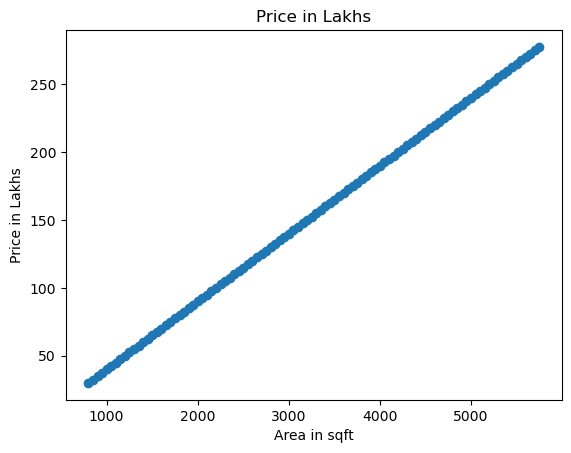

In [16]:
plt.scatter(df['Area_sqft'], df['Price_Lakhs'])
plt.xlabel('Area in sqft')
plt.ylabel('Price in Lakhs')
plt.title('Price in Lakhs')
plt.show()

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)

In [18]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [19]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
m = model.coef_
c = model.intercept_

predicted_y = model.predict(X_test)

In [21]:
model.predict(X_test.iloc[7].values.reshape(1,1))

C:\Users\sudhi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([97.5])

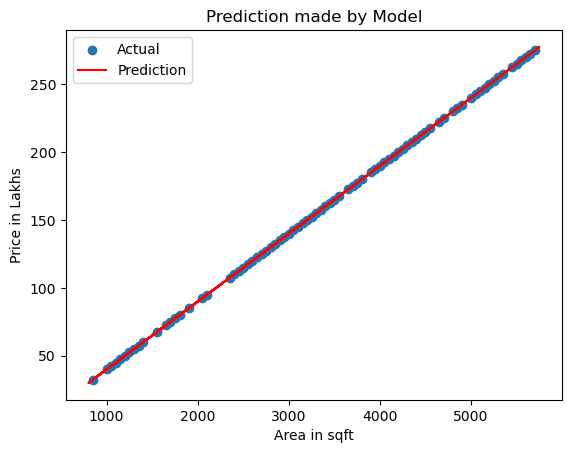

In [22]:
plt.scatter(X_train, y_train, label = 'Actual')
plt.plot(X_test, predicted_y, label = 'Prediction', color = 'red')
plt.xlabel('Area in sqft')
plt.ylabel('Price in Lakhs')
plt.legend()
plt.title('Prediction made by Model')
plt.show()

# Model Ready for predictions

In [24]:
print('House Price Predictor!\nPredict the price of your dream house by giving the input as the sqft of your house required.\nNote: Output is in Lakhs')
area = float(input("Enter the Area in sqft: "))
input_data = pd.DataFrame({
    'Area': [area]
})
prediction = model.predict(input_data)

print(f"\nApprox. {prediction[0]:.2f} Lakhs")

House Price Predictor!
Predict the price of your dream house by giving the input as the sqft of your house required.
Note: Output is in Lakhs


Enter the Area in sqft:  900



Approx. 35.00 Lakhs


In [25]:
import pickle

with open('house_price_model.pkl', 'wb') as file:
    pickle.dump(model, file)